In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


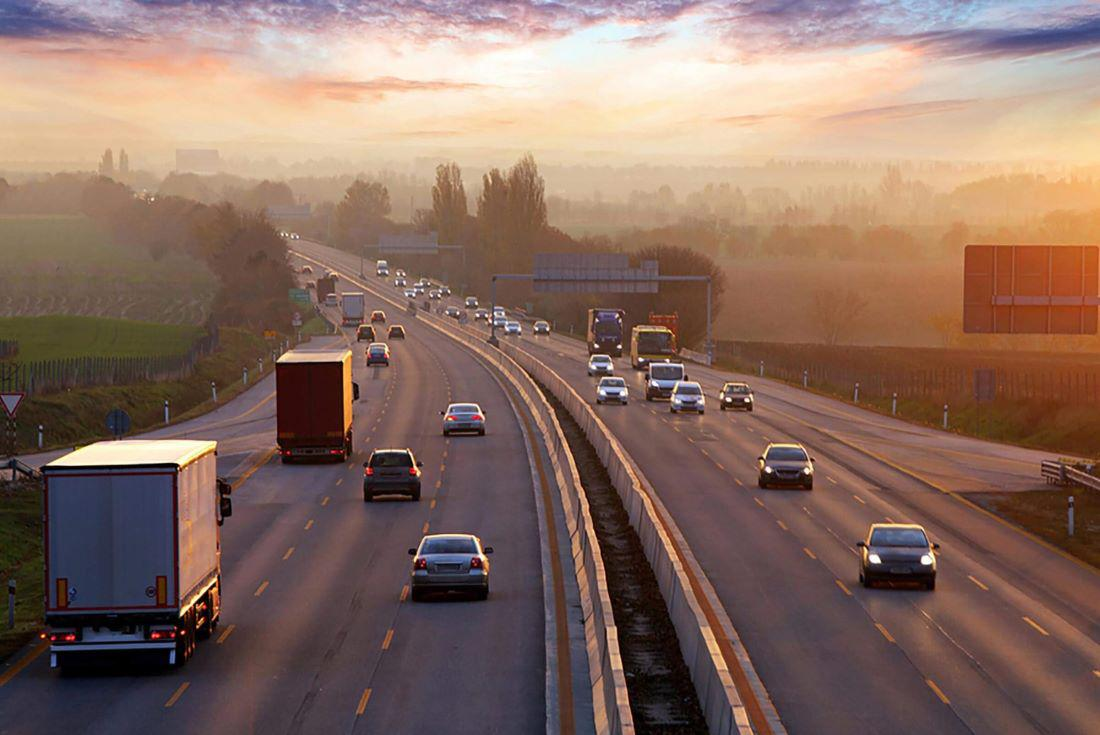

In [4]:
import cv2
from google.colab.patches import cv2_imshow
image_path = "/content/drive/My Drive/IPCV/image.jpg"
image = cv2.imread(image_path)
cv2_imshow(image)

Grayscale image shape: (735, 1100)


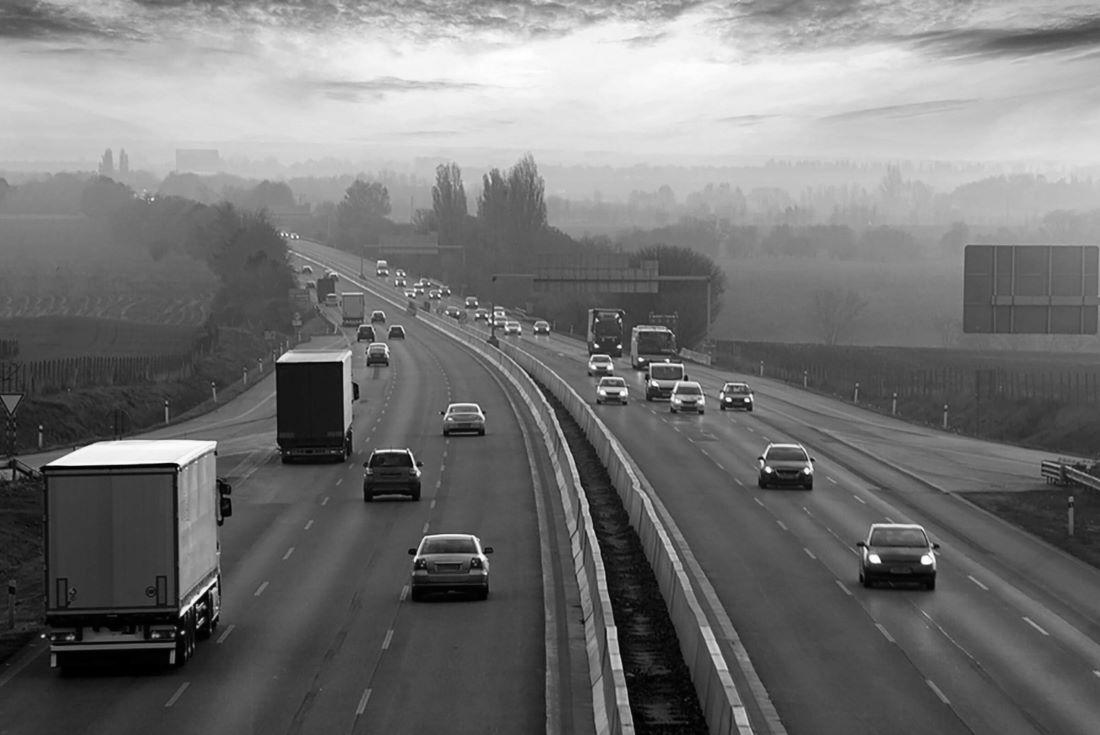

In [5]:
import cv2

# Convert the image to grayscale
# Assuming 'image' is already loaded as a color image from a previous cell.
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Grayscale image shape:", gray_image.shape)
cv2_imshow(gray_image)

In [6]:
import numpy as np

# Initialize hist array with zeros of size 256
hist = np.zeros(256, dtype=int)

# Iterate through each pixel and increment the corresponding histogram bin
for row in gray_image:
    for pixel_value in row:
        hist[pixel_value] += 1

print("Histogram computed :")
print(hist)

Histogram computed :
[  901  1575  1359  1218  1133   934   833   836   851   936  1008  1044
  1093  1087  1067  1157  1133  1160  1198  1151  1340  1590  2536  1800
  2451  1659  1288  1293  1298  1334  1401  1455  1439  1520  1487  1576
  1683  1728  1868  1967  2097  2121  2161  2155  2295  2279  2258  2354
  2429  2781  3250  3172  3629  3216  3442  3724  3665  4865  4563  4624
  4627  5305  5316  5496  5770  6026  6640  7561  8513  8614  8881  9632
 10506 10487  9834  9330  8772  8811  9183  9280  8463  8050  7938  8293
  8011  8029  7393  7048  7018  7120  7422  6975  6781  6472  6788  6407
  5946  5595  5324  5236  5525  5463  5288  5003  5008  5239  5264  5174
  4975  4870  5256  4892  5233  4555  4320  4227  3843  3690  3363  3107
  3132  2979  3082  3169  2976  2722  2507  2782  2679  2605  2416  2486
  2251  2388  2332  2049  2014  2074  2039  2219  1824  1689  1545  1530
  1547  1626  1509  1441  1518  1626  1684  1732  1657  1612  1651  1605
  1522  1622  1608  1652  1797

In [7]:
total_pixels = gray_image.shape[0] * gray_image.shape[1]
normalized_hist=hist/total_pixels
normalized_hist

array([1.11440940e-03, 1.94805195e-03, 1.68089054e-03, 1.50649351e-03,
       1.40136054e-03, 1.15522573e-03, 1.03030303e-03, 1.03401361e-03,
       1.05256648e-03, 1.15769944e-03, 1.24675325e-03, 1.29128015e-03,
       1.35188621e-03, 1.34446506e-03, 1.31972789e-03, 1.43104515e-03,
       1.40136054e-03, 1.43475572e-03, 1.48175634e-03, 1.42362400e-03,
       1.65739023e-03, 1.96660482e-03, 3.13667285e-03, 2.22634508e-03,
       3.03153989e-03, 2.05194805e-03, 1.59307359e-03, 1.59925788e-03,
       1.60544218e-03, 1.64996908e-03, 1.73283859e-03, 1.79962894e-03,
       1.77983921e-03, 1.88002474e-03, 1.83920841e-03, 1.94928881e-03,
       2.08163265e-03, 2.13729128e-03, 2.31045145e-03, 2.43290043e-03,
       2.59369202e-03, 2.62337662e-03, 2.67285096e-03, 2.66542981e-03,
       2.83858998e-03, 2.81880025e-03, 2.79282622e-03, 2.91156463e-03,
       3.00432900e-03, 3.43970315e-03, 4.01978973e-03, 3.92331478e-03,
       4.48855906e-03, 3.97773655e-03, 4.25726654e-03, 4.60606061e-03,
      

<Axes: ylabel='Count'>

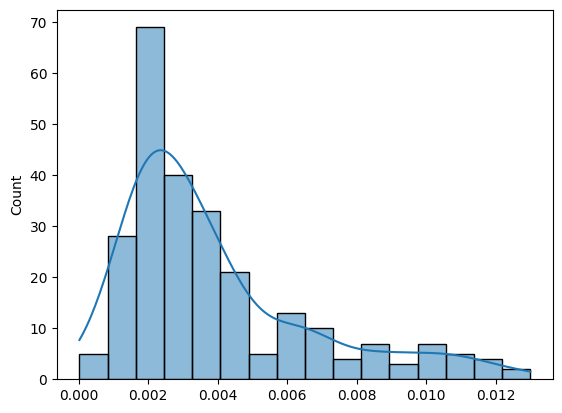

In [8]:
import seaborn as sns
sns.histplot(normalized_hist,kde=True)


In [9]:
# Compute the Cumulative Distribution Function (CDF)
cdf = normalized_hist.cumsum()

print("Cumulative Distribution Function (CDF):")
print(cdf)

Cumulative Distribution Function (CDF):
[0.00111441 0.00306246 0.00474335 0.00624985 0.00765121 0.00880643
 0.00983673 0.01087075 0.01192331 0.01308101 0.01432777 0.01561905
 0.01697093 0.0183154  0.01963513 0.02106617 0.02246753 0.02390229
 0.02538404 0.02680767 0.02846506 0.03043166 0.03356834 0.03579468
 0.03882622 0.04087817 0.04247124 0.0440705  0.04567594 0.04732591
 0.04905875 0.05085838 0.05263822 0.05451824 0.05635745 0.05830674
 0.06038837 0.06252566 0.06483612 0.06726902 0.06986271 0.07248609
 0.07515894 0.07782437 0.08066296 0.08348176 0.08627458 0.08918615
 0.09219048 0.09563018 0.09964997 0.10357328 0.10806184 0.11203958
 0.11629685 0.12090291 0.12543599 0.13145331 0.13709709 0.14281633
 0.14853927 0.1551008  0.16167594 0.16847372 0.17561039 0.1830637
 0.19127644 0.20062832 0.2111577  0.221812   0.23279654 0.24470996
 0.25770439 0.27067532 0.28283859 0.29437848 0.3052282  0.31612616
 0.32748423 0.33896228 0.34942981 0.35938652 0.3692047  0.37946197
 0.38937044 0.39930118 

<Axes: ylabel='Count'>

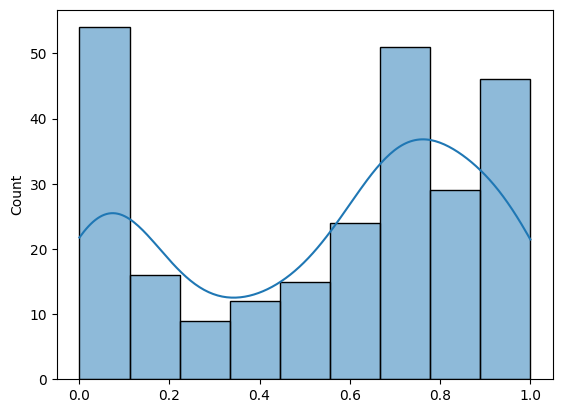

In [12]:
sns.histplot(cdf,kde=True)

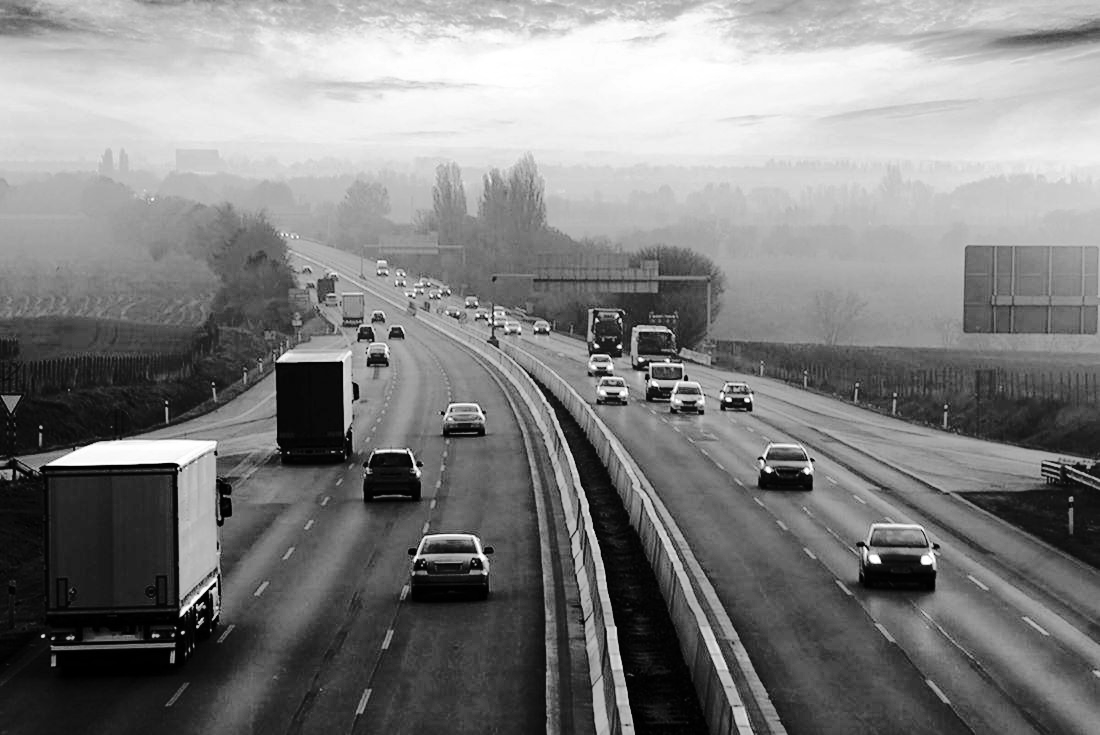

In [14]:

cdf_min=cdf.min()
cdf_max=cdf.max()
hist_eq_map = np.round(((cdf - cdf_min) / (1 - cdf_min)) * 255).astype(np.uint8)

# Apply the mapping to the grayscale image to get the equalized image
equalized_image = hist_eq_map[gray_image]


# Display the equalized image
cv2_imshow(equalized_image)

Probability Distribution Function (PDF) of Equalized Image:


<Axes: ylabel='Count'>

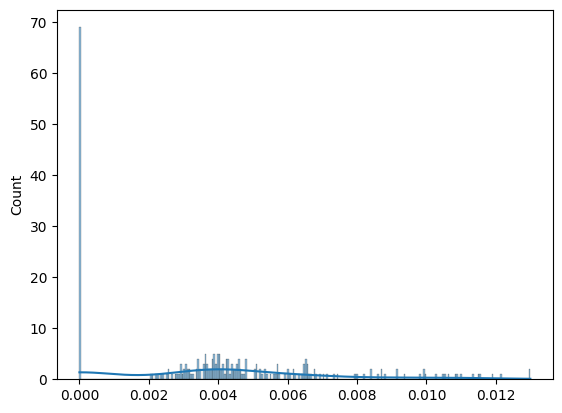

In [17]:
hist_equalized = np.zeros(256, dtype=int)
for row in equalized_image:
    for pixel_value in row:
        hist_equalized[pixel_value] += 1

total_pixels_equalized = equalized_image.shape[0] * equalized_image.shape[1]
normalized_hist_equalized = hist_equalized / total_pixels_equalized

print("Probability Distribution Function (PDF) of Equalized Image:")

sns.histplot(normalized_hist_equalized, kde=True, bins=256)
